**Task 1** Find the general solution of the _logistic differential equation_ $$y' = cy\left(1-\frac{y}{a}\right)  \textrm{, }$$ and the solution satisfying the condition $y(0) = b$.

**Task 2** Solve the initial value problem $$x y'+ y = -\sin(x) \textrm{, } y(\pi) = 0 \textrm{. }$$

**Task 3** Write a _Julia_ function `euler(f, Y0, (t0, tk), h)`, which approximately solves the differential equation $$y' = f(t, y) \quad \textrm{with initial condition} \quad y(t_0) = y_0$$ using the Euler method with step size `h`. The function should return a tuple `(t, Y)` of function values `Y` (a `Vector` of `Vector`s) evaluated at times `t`.

Solve DE's above using this method. Compare exact and numerical solutions.

In [13]:
function euler(f, Y0, (t0, tk), h)
    #y(t0) = Y0
    #evaluated at time t0+h, t0+2h,...,t0+n*h, tk
    #xi+1 = xi + h
    n = floor((tk-t0)/h)
    t0 = Float64(t0)
    y0 = Float64(Y0)
    Y = [y0]
    t = [t0]
    if (t0+n*h < tk)
        #last point is tk
        lp = true
    else
        lp = false
    end

    for i in 1:n
        y0 += h*f(t0, y0) 
        t0 += h
        push!(Y, y0)
        push!(t, t0)
    end

    if lp
        t0 = tk
        y0 += h*f(t0, y0)
        push!(Y, y0)
        push!(t, t0)
    end

    return (t, Y)
end

euler (generic function with 1 method)

In [14]:
f(x, y) = (-sin(x) - y)/x
Y0 = 0.0
t0 = pi
tk = 2*pi
h = 0.01

euler(f, Y0, (t0, tk), h)

([3.141592653589793, 3.151592653589793, 3.1615926535897927, 3.1715926535897925, 3.1815926535897923, 3.191592653589792, 3.201592653589792, 3.2115926535897916, 3.2215926535897914, 3.231592653589791  …  6.201592653589728, 6.211592653589728, 6.2215926535897275, 6.231592653589727, 6.241592653589727, 6.251592653589727, 6.261592653589727, 6.271592653589726, 6.281592653589726, 6.283185307179586], [0.0, -3.8981718325193754e-19, 3.1729460096234156e-5, 9.488414009767293e-5, 0.0001891604842825227, 0.0003142556112700838, 0.0004698673043962279, 0.0006556940025813922, 0.0008714347916802317, 0.0011167893963023074  …  0.3224128471741625, 0.3220243813253545, 0.32162111458821635, 0.32120310683419184, 0.32077041915156507, 0.3203231138366986, 0.31986125438519647, 0.3193849054829918, 0.31889413299736075, 0.3183865972214654])

0.0067647055296724545


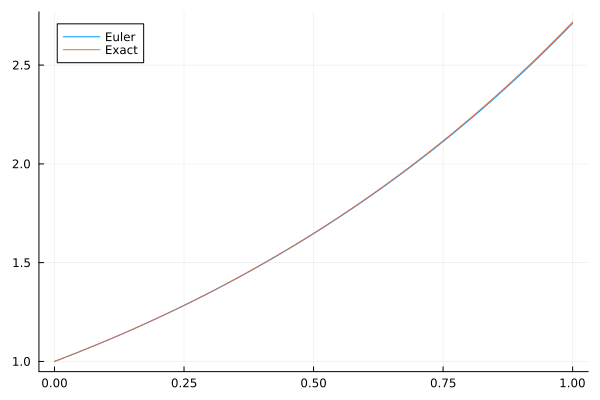

In [15]:
g(t, y) = y
t, Y = euler(g, 1.0, (0.0, 1.0), 0.005)

exact = exp.(t)
error = maximum(abs.(Y .- exact))

println(error)
using Plots

plot(t, Y, label="Euler")
plot!(t, exp.(t), label="Exact")

**Task 4** Write a _Julia_ function `rk4(f, Y0, (t0, tk), h)`, which approximately solves the differential equation $$y' = f(t,y) \quad \textrm{with initial condition} \quad y(t_0) = y_0$$ using the classical 4th order Runge--Kutta method; for step size `h` define
\begin{align*}
	k_1 &= h f(t_i, y_i) \\
	k_2 &= h f(t_i + h/2, y_i + k_1/2) \\
	k_3 &= h f(t_i + h/2, y_i + k_2/2) \\
	k_4 &= h f(t_i + h, y_i + k_3)
\end{align*}
and evaluate the next value with $$y_{i+1} = y_i + \tfrac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) \textrm{. }$$ 
The function should return a tuple `(t, Y)` of function values `Y` (a `Vector` of `Vector`s) evaluated at times `t`.

Solve DE's above using this method. Compare exact and numerical solutions.

In [17]:
function rk4(f, Y0, (t0, tk), h)
    y0 = Float64(Y0)
    t0 = Float64(t0)
    tk = Float64(tk)
    n = floor((tk-t0)/h)
    Y = [y0]
    t = [t0]
    if (t0+n*h < tk)
        #last point is tk
        lp = true
    else
        lp = false
    end

    for i in 1:n
        k1 = h*f(t0, y0)
        k2 = h*f(t0 + h/2, y0 + k1/2)
        k3 = h*f(t0 + h/2, y0 + k2/2)
        k4 = h*f(t0 + h, y0 + k3)
        y0 += 1/6 * (k1 + 2*k2 + 2*k3 + k4)
        t0 += h 
        push!(Y, y0)
        push!(t, t0)
    end

    if lp
        t0 = tk
        k1 = h*f(t0, y0)
        k2 = h*f(t0 + h/2, y0 + k1/2)
        k3 = h*f(t0 + h/2, y0 + k2/2)
        k4 = h*f(t0 + h, y0 + k3)
        y0 += 1/6 * (k1 + 2*k2 + 2*k3 + k4)
        push!(Y, y0)
        push!(t, t0)
    end

    return (t, Y)
end

rk4 (generic function with 1 method)

1.4100720591159188e-11


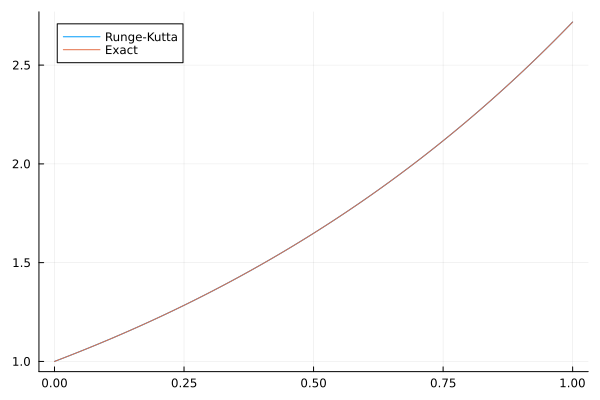

In [19]:
rk4(f, Y0, (t0, tk), h)
g(t, y) = y
t, Y = rk4(g, 1.0, (0.0, 1.0), 0.005)

exact = exp.(t)
error = maximum(abs.(Y .- exact))

println(error)
using Plots

plot(t, Y, label="Runge-Kutta")
plot!(t, exp.(t), label="Exact")